# Decision Tree

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("/content/drive/MyDrive/heart.csv")

In [3]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [4]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
X = df.drop('target', axis=1)
y = df['target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)
clf.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10)

In [9]:
y_pred =clf.predict(X_test_scaled)

In [10]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [11]:
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.8214
Confusion Matrix:
[[114  45]
 [ 10 139]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.72      0.81       159
           1       0.76      0.93      0.83       149

    accuracy                           0.82       308
   macro avg       0.84      0.82      0.82       308
weighted avg       0.84      0.82      0.82       308



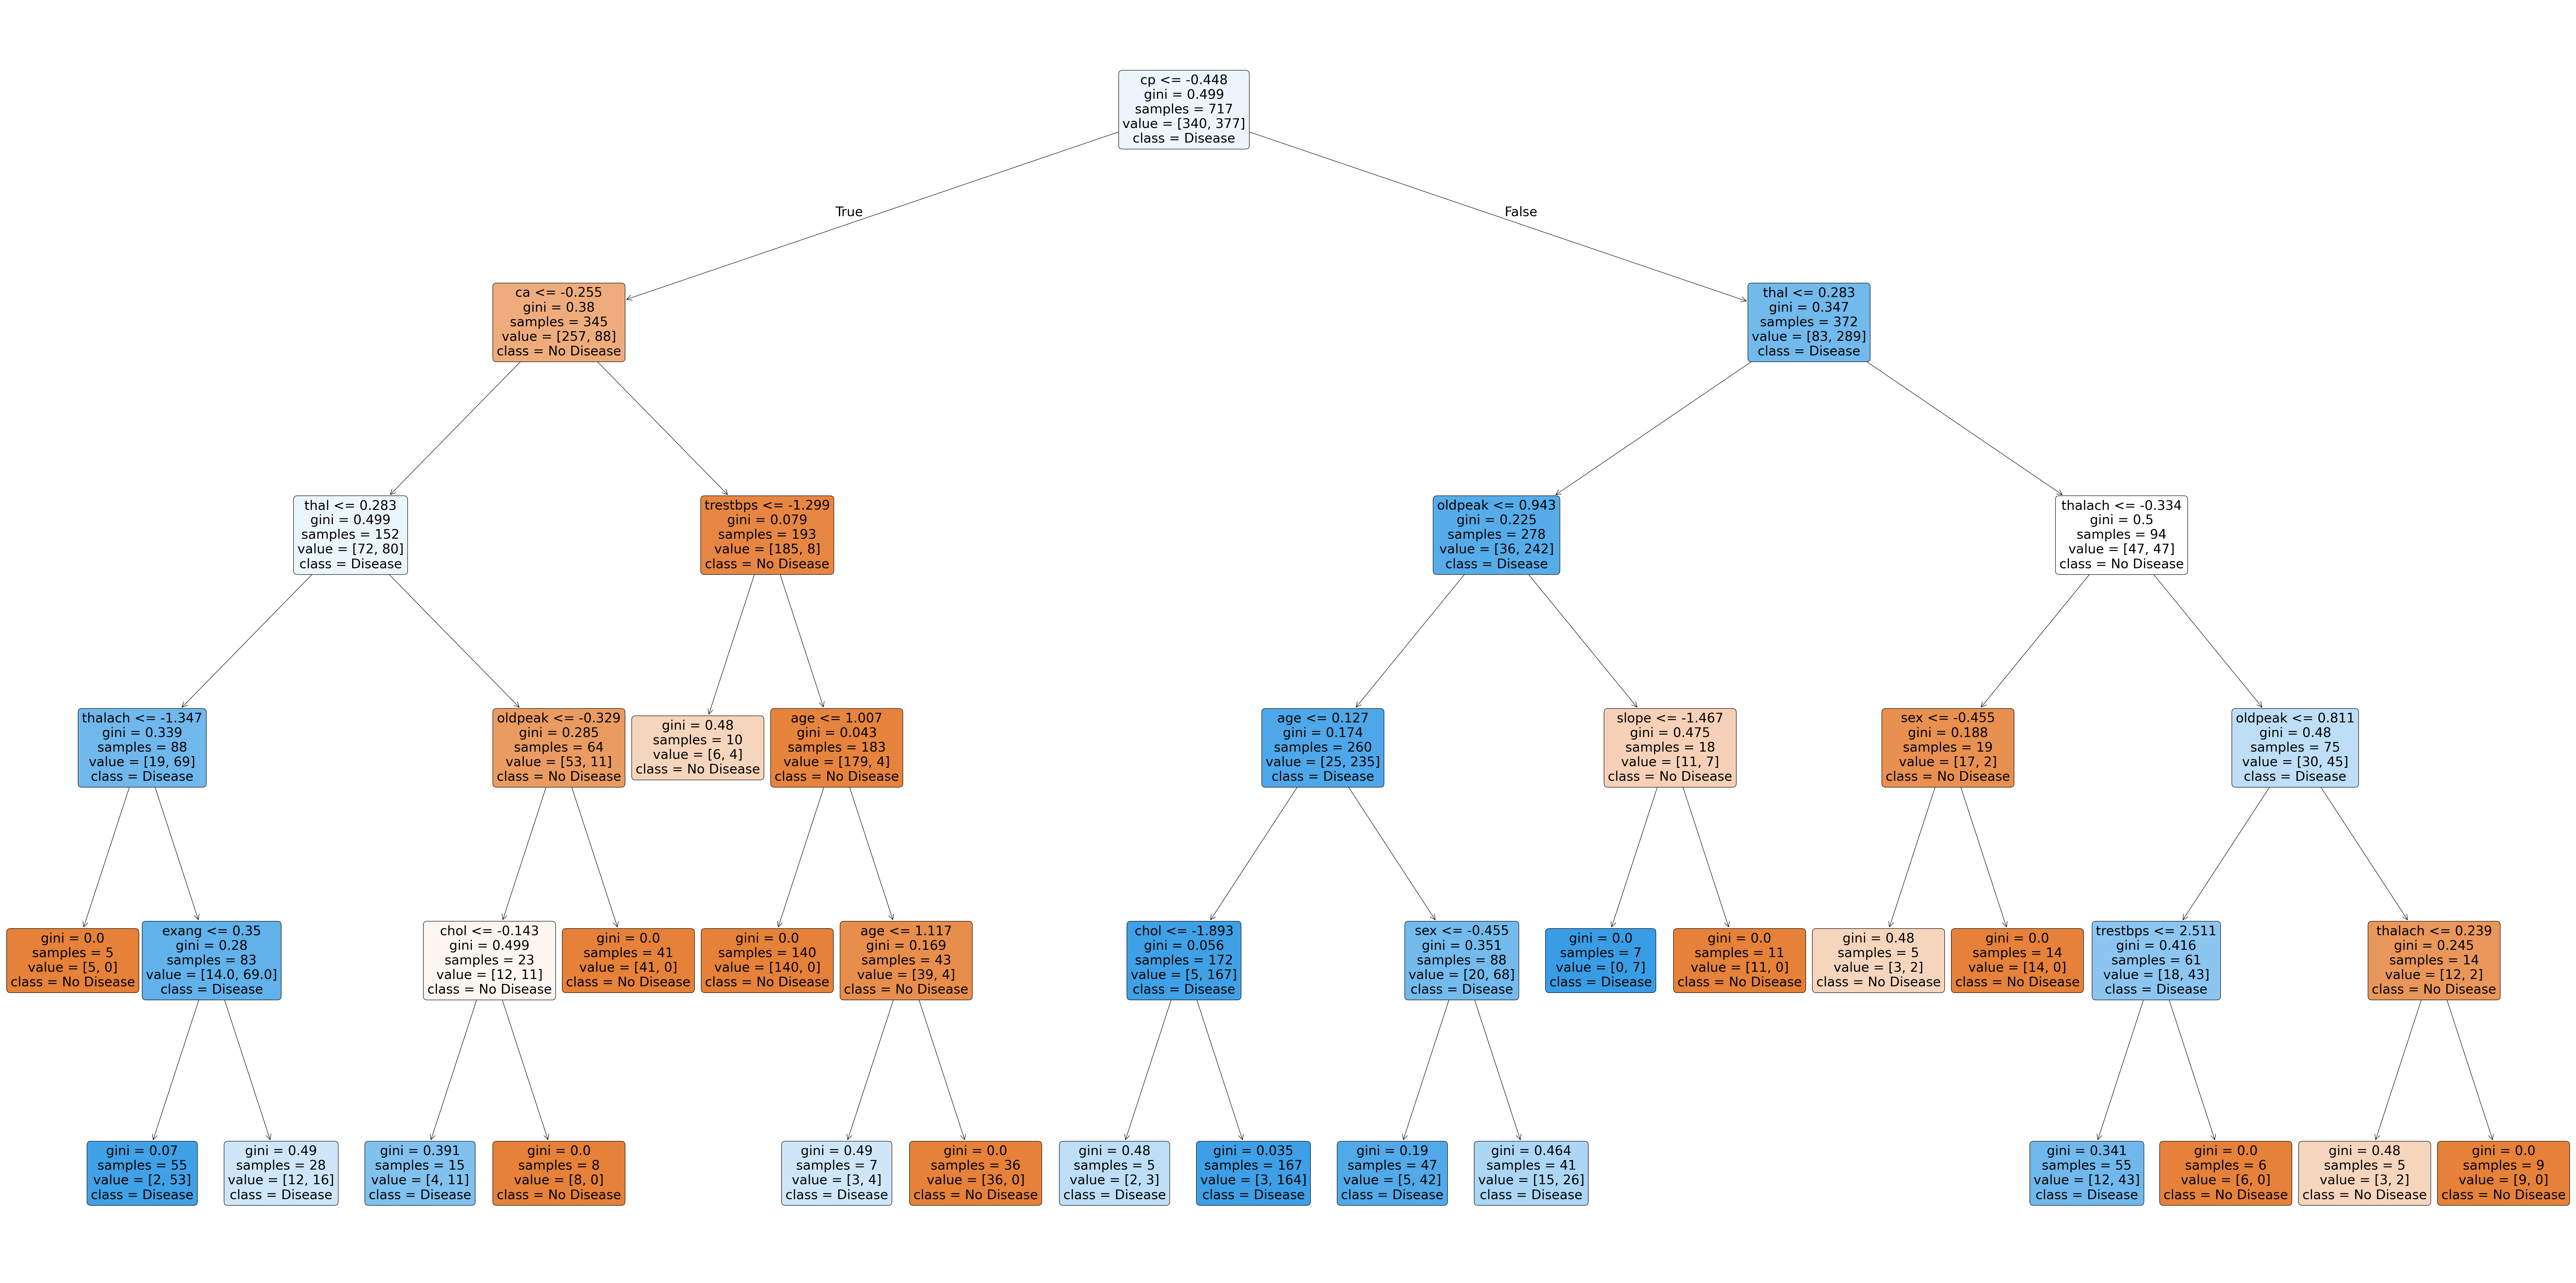

In [13]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(100,50))
plot_tree(
    clf,
    filled=True,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    rounded=True
)
plt.show()

To prevent **overfitting** in a **decision tree**, follow these **3 key steps**:

---

### 1. **Limit Tree Depth**
- Set a **maximum depth** (`max_depth`) to restrict how deep the tree can grow.
- Deep trees can capture noise in training data, leading to overfitting.

---

### 2. **Set Minimum Samples for Split/Leaf**
- Use parameters like:
  - `min_samples_split`: Minimum number of samples needed to split a node.
  - `min_samples_leaf`: Minimum number of samples required to be at a leaf node.
- This prevents the model from creating small, overly specific branches.

---

### 3. **Use Pruning**
- **Post-pruning** (also called cost-complexity pruning) removes branches that have little predictive power.
- In `sklearn`, use `ccp_alpha` (complexity parameter) to prune after training.


In [17]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf, X_train_scaled, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())

Cross-validation scores: [0.86805556 0.81944444 0.8951049  0.88111888 0.8041958 ]
Average cross-validation score: 0.853583916083916



Feature Importances:
 cp          0.366361
thal        0.176879
ca          0.150268
oldpeak     0.085931
thalach     0.056257
trestbps    0.035048
age         0.033715
slope       0.032156
chol        0.026417
exang       0.021454
sex         0.015513
fbs         0.000000
restecg     0.000000
dtype: float64


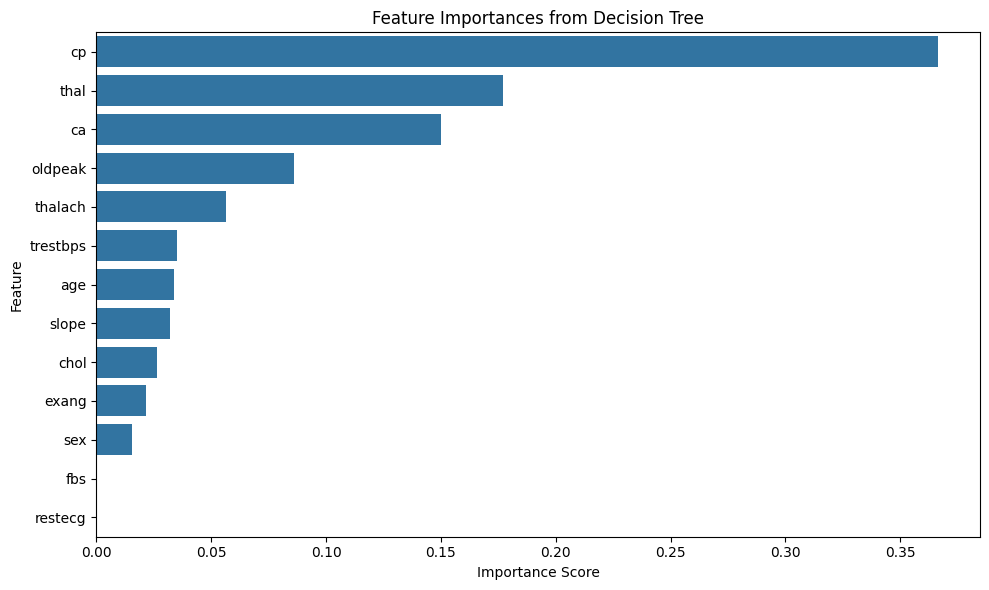

In [27]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:\n", importances)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importances from Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Random Forest

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [19]:
data = pd.read_csv("/content/drive/MyDrive/heart.csv")

In [20]:
X = data.drop("target", axis=1)
y = data["target"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [22]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [23]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9805


In [24]:
cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Validation Accuracy: 0.9971 ± 0.0059



Feature Importances:
 cp          0.132274
thalach     0.125039
ca          0.122912
oldpeak     0.122852
thal        0.113005
age         0.085554
chol        0.079872
trestbps    0.068356
slope       0.051335
exang       0.042210
sex         0.028721
restecg     0.018155
fbs         0.009714
dtype: float64


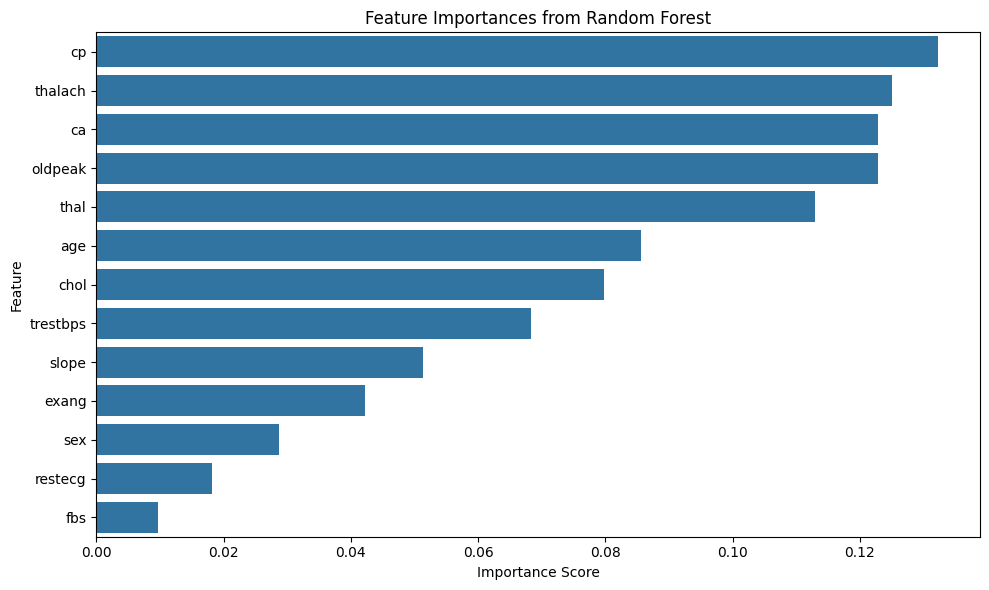

In [25]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:\n", importances)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()